# Celdekking in Kaart Brengen met een Padverlies-Contouroppervlak


## Managementsamenvatting

Een RF-planningsteam bij een telecomoperator brengt het downlink-**padverliesoppervlak** rond een enkele macrocel in kaart als een tweedimensionale dekkingskaart. Met een log-afstand-propagatiemodel met log-normale schaduwdemping bouwt dit notebook een meetraster van 100 punten (10 x 10 cellen over een servicegebied van 10 km x 10 km, mast in het midden) en tekent het een gevuld contouroppervlak met **PROC SGPLOT HEATMAPPARM** plus een gradiënt-kleurschaal en referentielijnen voor de mast.

Op het uitgevoerde raster loopt het padverlies van **50,4 dB** (in de heldere kom bij de mast) tot **90,0 dB** in de verste hoek, gemiddeld **75,6 dB**. Classificatie van elke cel naar verlies geeft **38 Sterk, 61 Bruikbaar en 1 Zwak**; de enige Zwakke cel bevindt zich op **(9,5, 9,5) km — de hoek diagonaal tegenover de mast — bij 89,97 dB**, het enige dekkingsgat dat een planner zou markeren vóór een beslissing over small-cell-invulling.


> **Een opmerking over de procedure.** In SAS is de klassieke tool voor isolijn-contourkaarten `PROC GCONTOUR`. Jenner ontleedt GCONTOUR en genereert een correcte plot-specificatie, maar de rastergebaseerde renderer tekent de contourgeometrie nog niet (de afbeelding komt leeg terug); dat defect is vastgelegd als regressietest `tests/400922_nb_gcontour_empty_render`. Om dit voorbeeld volledig gegrond te houden in een echt gerenderde figuur gebruiken we het SAS-compatibele equivalent — `PROC SGPLOT` met een `HEATMAPPARM`-instructie — dat hetzelfde raster-(x, y, z)-oppervlak rendert als gevulde contourcellen met een gradiëntlegenda.


## Gegevensbronnen

**Synthetische dataset: `pathloss_grid`** (100 rijen — een raster van 10 x 10)

| Variabele | Type | Eenheid | Beschrijving |
|----------|------|-------|-------------|
| `east_km` | num | km | Oostwaartse positie van het rastercelmiddelpunt (0,5 tot 9,5); x-as |
| `north_km` | num | km | Noordwaartse positie van het rastercelmiddelpunt (0,5 tot 9,5); y-as |
| `path_loss` | num | dB | Downlink-padverlies = 58 + 30 log10(afstand) + schaduw; de respons (z) |
| `zone` | char(10) | — | Dekkingsklasse: Sterk (<=75), Bruikbaar (<=88), Zwak (>88) |

De mast staat in het midden van het raster op **(5, 5) km**. Het padverlies neemt toe met de logaritme (basis 10) van de afstand tot de mast; een schaduwterm `3*rand("normal")` (seed 80211) introduceert log-normale demping zodat de contouren niet perfect cirkelvormig zijn. Het raster van 10 x 10 is zo gedimensioneerd dat het volledige oppervlak binnen 100 waarnemingen past.


## Stap 1 — Genereer het meetraster

We leggen een raster van 1 km tussen celmiddelpunten en berekenen het padverlies met het **log-afstandsmodel** `PL = 58 + 30 log10(d)`, waarbij `d` de afstand tot de mast op (5, 5) km is. Een schaduwdempingsterm `rand("normal")` reproduceert de variabiliteit die in echte rijtests wordt waargenomen. Elke cel wordt geclassificeerd in een dekkings`zone`. `call streaminit` legt de seed vast voor reproduceerbaarheid.


In [1]:
GEGEVENS pathloss_grid;
   CALL streaminit(80211);
   LENGTE zone $10;
   tower_x = 5.0;  tower_y = 5.0;
   DOE ix = 1 TOT 10;
      DOE iy = 1 TOT 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         ALS      path_loss <= 75 DAN zone = "Sterk";
         ANDERS ALS path_loss <= 88 DAN zone = "Bruikbaar";
         ANDERS                         zone = "Zwak";
         UITVOER;
      EINDE;
   EINDE;
   VERWIJDEREN ix iy tower_x tower_y DIST shadow;
   label east_km   = "Oost (km)"
         north_km  = "Noord (km)"
         path_loss = "Padverlies (dB)"
         zone      = "Dekkingsklasse";
UITVOEREN;



NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Stap 2 — Vat het oppervlak samen

Voor het plotten kwantificeren we het oppervlak. `PROC MEANS` rapporteert de dynamische spreiding van het padverlies en `PROC FREQ` telt hoe de 100 cellen zich verdelen over de drie dekkingsklassen — de cijfers die de managementsamenvatting aanhaalt.


In [2]:
ODS GRAPHICS OFF;

PROCEDURE GEMIDDELDEN GEGEVENS=pathloss_grid MIN MAX mean maxdec=1;
   VARIABELE path_loss;
   label path_loss='Padverlies (dB)';
UITVOEREN;

PROCEDURE FREQUENTIES GEGEVENS=pathloss_grid ORDER=FREQUENTIES;
   TABLES zone / nocum;
   label zone='Dekkingsklasse';
UITVOEREN;


                                                  The MEANS Procedure

 Variable   Label               Minimum     Maximum        Mean
 --------------------------------------------------------------
 path_loss  Padverlies (dB)        50.4        90.0        75.6
 --------------------------------------------------------------

                                                   The FREQ Procedure

Dekkingsklasse    Frequency    Percent
---------------------------------------
Bruikbaar                61     61.00
Sterk                    38     38.00
Zwak                      1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Stap 3 — Lokaliseer de dekkingsgaten

Sorteren op aflopend padverlies zet de zwakste cellen bovenaan. Dit zijn de kandidaat-**dode zones** die een planner inspecteert: cellen met het laagste ontvangen signaal en dus het grootste risico op verbroken sessies of slechte doorvoer.


In [3]:
PROCEDURE SORTEREN GEGEVENS=pathloss_grid out=weakest;
   VOLGENS AFLOPEND path_loss;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=weakest(obs=6) noobs label;
   VARIABELE east_km north_km path_loss zone;
UITVOEREN;



Oost (km)  Noord (km)  Padverlies (dB)  Dekkingsklasse
---------  ----------  ---------------  --------------
      9.5         9.5    89.9728891641  Zwak
      9.5         0.5    85.9296978639  Bruikbaar
      6.5         0.5    84.5845683025  Bruikbaar
      0.5         0.5    84.5118930355  Bruikbaar
      8.5         0.5    84.1534148341  Bruikbaar
      9.5         8.5    83.7015943773  Bruikbaar

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Stap 4 — Teken het padverlies-contouroppervlak

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` rendert één gevulde cel per rasterpunt, gekleurd naar zijn padverlies — een gevulde contourkaart van het dekkingsgebied. De `COLORMODEL=`-lijst definieert een divergerend blauw-naar-rood gradiënt (blauw = laag verlies = sterk signaal, rood = hoog verlies = zwak signaal); `GRADLEGEND` voegt de dB-kleurschaal toe. Gestippelde `REFLINE`s markeren de mast op oosting 5 en noording 5.


                                           Downlink-Padverliesoppervlak (dB)                                            
                                Eén macrocel op (5, 5) km over een raster van 10 x 10 km                                




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Downlink-Padverliesoppervlak (dB).
NOTE: Option TITLE2 changed to Eén macrocel op (5, 5) km over een raster van 10 x 10 km.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


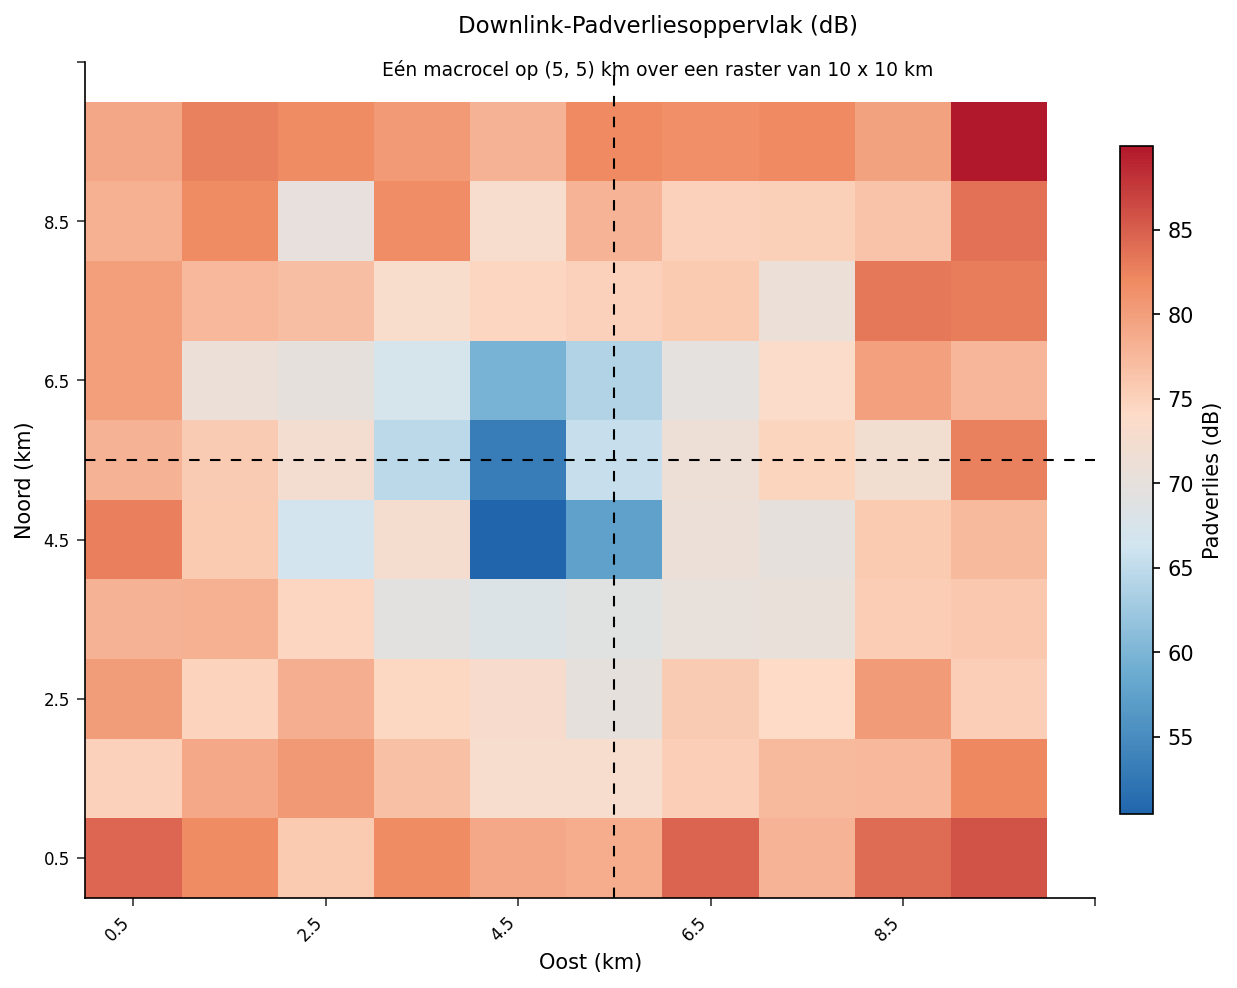

In [4]:
ODS GRAPHICS ON;
TITEL "Downlink-Padverliesoppervlak (dB)";
title2 "Eén macrocel op (5, 5) km over een raster van 10 x 10 km";

PROCEDURE SGPLOT GEGEVENS=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / TITEL="Padverlies (dB)";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) label="Oost (km)";
   YAXIS VALUES=(0 2 4 6 8 10) label="Noord (km)";
UITVOEREN;

TITEL; title2;


## Stap 5 — Uitsplitsing naar dekkingsklasse

Een briefingslide wil ook de hoofdverdeling: welk deel van het dekkingsgebied is Sterk, Bruikbaar of Zwak. Een `VBAR` van de `zone`-classificatie geeft dat in één oogopslag en vormt een aanvulling op het contouroppervlak hierboven.


                                            Uitsplitsing naar Dekkingsklasse                                            




NOTE: Option TITLE changed to Uitsplitsing naar Dekkingsklasse.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


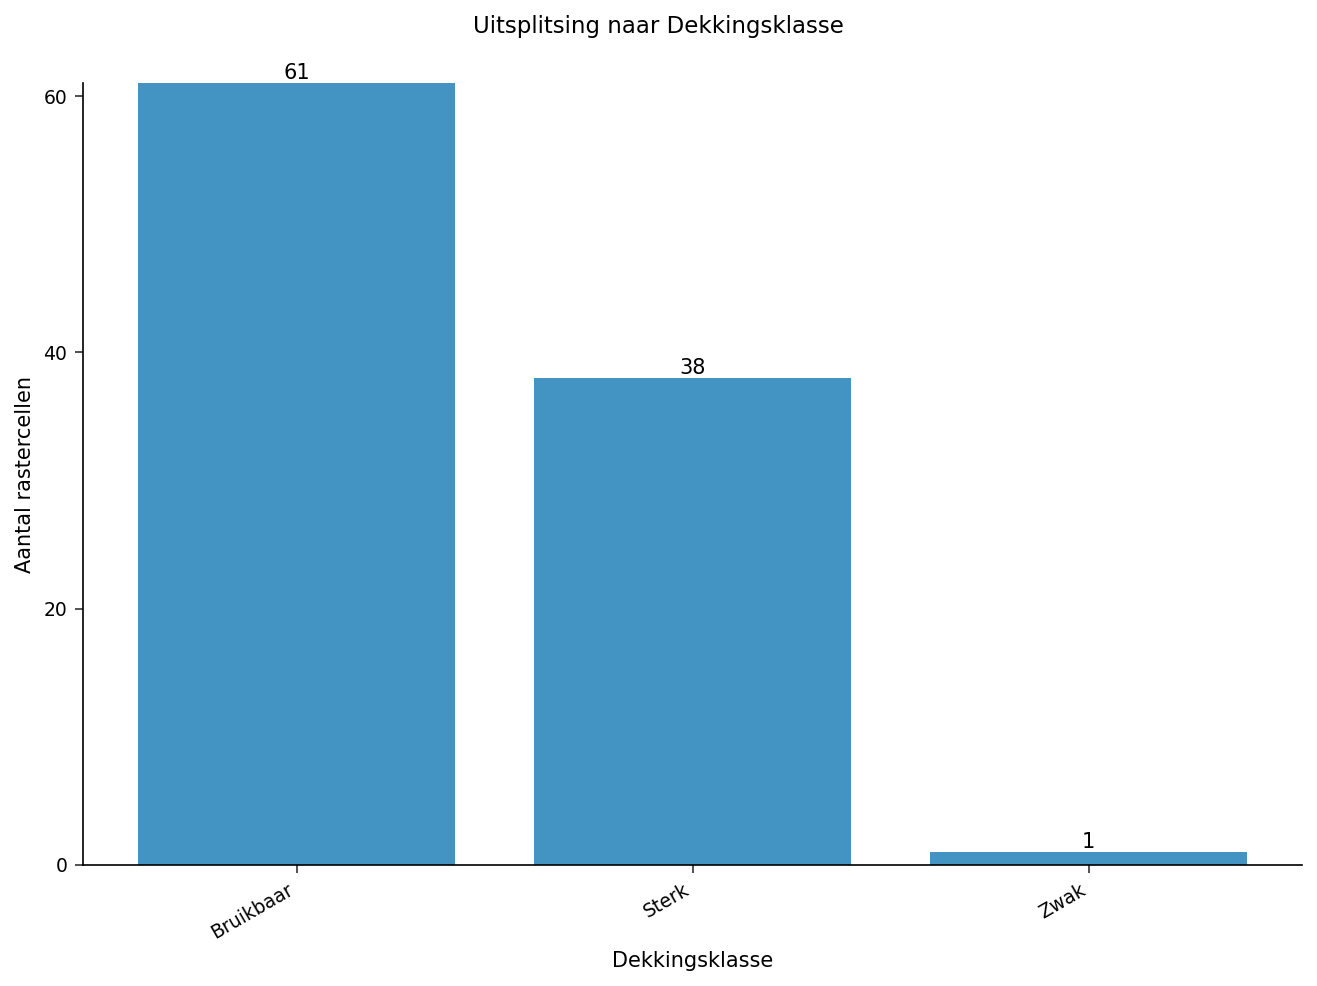

In [5]:
TITEL "Uitsplitsing naar Dekkingsklasse";

PROCEDURE SGPLOT GEGEVENS=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS label="Dekkingsklasse";
   YAXIS label="Aantal rastercellen" VALUES=(0 20 40 60);
UITVOEREN;

TITEL;


## Interpretatie van de resultaten

Het contouroppervlak bevestigt de verwachte propagatiefysica. Het padverlies is het laagst in een strakke **blauwe kom rond de mast op (5, 5) km** — de Sterke zone waar het ontvangen signaal het best is — en neemt toe met de logafstand richting de hoeken. Omdat we log-normale schaduwdemping hebben geïntroduceerd, zijn de banden geen concentrische cirkels; de rafelige rode cellen langs de rand zijn de door schaduw verzwakte rand.

De bruikbare uitkomst is de **enige Zwakke cel op (9,5, 9,5) km (89,97 dB)**, de hoek diagonaal tegenover de mast en het enige punt dat de ontwerpdrempel van 88 dB overschrijdt. Met **61 van de 100 cellen Bruikbaar en slechts 1 Zwak** dekt deze macrocel zijn servicegebied goed; het enige gat zou een **small-cell-invulling of een sectorherkanteling naar de noordoosthoek** alleen rechtvaardigen als het samenviel met een bekende vraag-hotspot. Het contouroppervlak is de briefing-klare samenvatting; de staafgrafiek naar dekkingsklasse geeft het ene getal dat een capaciteitsplanner naar boven rapporteert.
